# Book Dataset Analysis and Preprocessing

This notebook performs a comprehensive analysis and preprocessing of a book metadata dataset. Following are the targets of this notebook:

1. Download and load the dataset from Kaggle
2. Explore data quality by analyzing missing values
3. Create derived features for better analysis
4. Filter and clean the data to ensure quality
5. Prepare the dataset for downstream tasks like semantic search and recommendation systems



In [1]:
# Import necessary libraries for dataset download
import kagglehub

# Retrieve the book metadata dataset from Kaggle
dataset_path = kagglehub.dataset_download("dylanjcastillo/7k-books-with-metadata")

print(f"Dataset location: {dataset_path}")


Dataset location: /Users/omagarwal/.cache/kagglehub/datasets/dylanjcastillo/7k-books-with-metadata/versions/3


## 1. Dataset Download

We use the `kagglehub` library to download the book metadata dataset. This dataset contains information about thousands of books including titles, descriptions, ratings, publication years, and more.


In [2]:
# Import data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Library Imports and Setup

Import the necessary libraries for data manipulation (pandas, numpy) and visualization (matplotlib, seaborn). We also configure the visualization style for consistent and appealing plots.


In [3]:
# Load the book dataset into a DataFrame
df_books = pd.read_csv(f"{dataset_path}/books.csv")

# Display basic information about the dataset
print(f"Dataset shape: {df_books.shape}")
print(f"\nColumn names: {list(df_books.columns)}")
df_books.head()


Dataset shape: (6810, 12)

Column names: ['isbn13', 'isbn10', 'title', 'subtitle', 'authors', 'categories', 'thumbnail', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count']


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0


## 3. Loading the Dataset

Loads the books dataset into a pandas DataFrame to examine the basic structure of the dataset including its dimensions and column names.


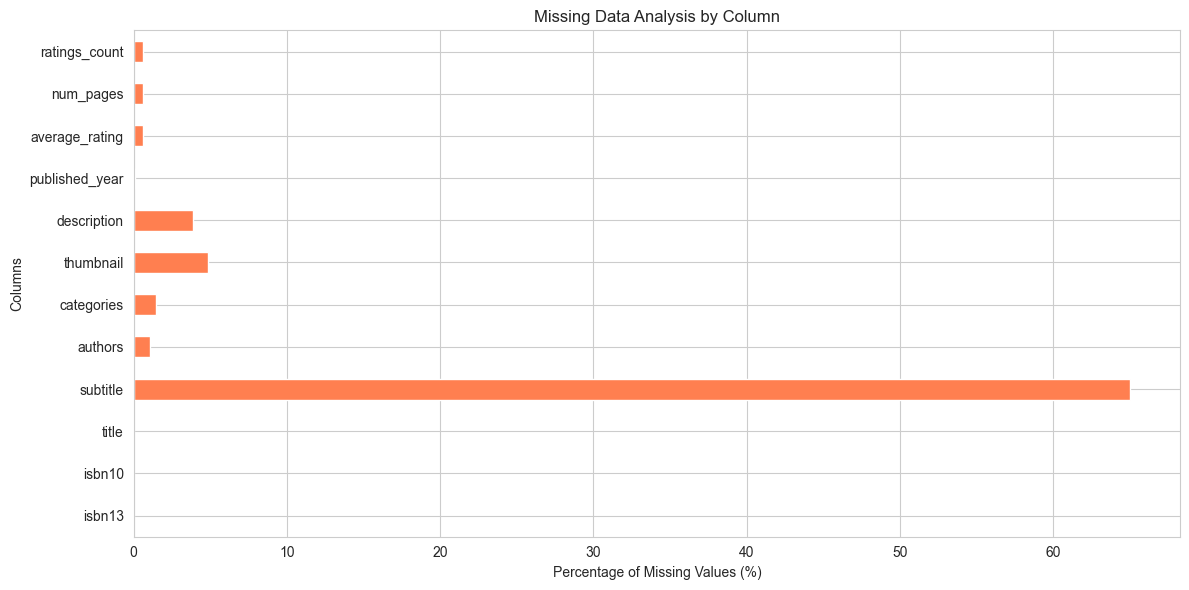

Missing values summary:
subtitle          4429
authors             72
categories          99
thumbnail          329
description        262
published_year       6
average_rating      43
num_pages           43
ratings_count       43
dtype: int64


In [4]:
# Analyze missing data patterns across all columns
missing_data = df_books.isnull().sum()
missing_percentage = (missing_data / len(df_books)) * 100

# Create a bar plot for missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_percentage.plot(kind='barh', ax=ax, color='coral')
ax.set_xlabel('Percentage of Missing Values (%)')
ax.set_title('Missing Data Analysis by Column')
ax.set_ylabel('Columns')
plt.tight_layout()
plt.show()

print("Missing values summary:")
print(missing_data[missing_data > 0])


## 4. Missing Data Analysis

Before proceeding with analysis, it's crucial to understand the data quality. So, we identify which columns have missing values and visualize the extent of missing data. This helps us make informed decisions about data cleaning strategies.


In [5]:
# Create derived features for analysis
# Feature 1: Binary indicator for missing descriptions
df_books['has_description'] = df_books['description'].notna().astype(int)

# Feature 2: Calculate years since publication
current_year = 2025
df_books['years_since_publication'] = current_year - df_books['published_year']

# Display summary statistics
print("New features created:")
print(f"Books with descriptions: {df_books['has_description'].sum()}")
print(f"Books without descriptions: {(df_books['has_description'] == 0).sum()}")
print(f"\nYears since publication statistics:")
print(df_books['years_since_publication'].describe())


New features created:
Books with descriptions: 6548
Books without descriptions: 262

Years since publication statistics:
count    6804.000000
mean       26.369636
std        10.484257
min         6.000000
25%        20.000000
50%        23.000000
75%        29.000000
max       172.000000
Name: years_since_publication, dtype: float64


## 5. Feature Engineering

We create new features that can be useful for analysis. These features can help us understand patterns in the data and may be useful for modeling.
- has_description: A binary indicator (1/0) showing whether a book has a description
- years_since_publication: Calculates how many years have passed since the book was published




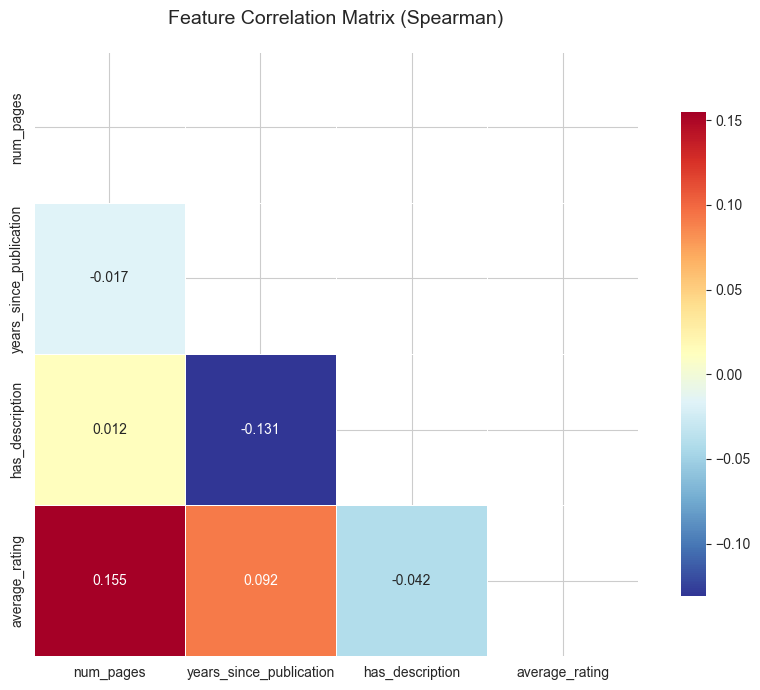

In [6]:
# Select numeric features for correlation analysis
numeric_features = ["num_pages", "years_since_publication", "has_description", "average_rating"]

# Compute Spearman rank correlation
corr_data = df_books[numeric_features].corr(method='spearman')

# Visualize correlation matrix
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_data, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.3f', cmap='RdYlBu_r',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix (Spearman)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()


## 6. Correlation Analysis

Examine relationships between key numeric features using Spearman rank correlation. This non-parametric correlation method is robust to outliers and doesn't assume linear relationships. The correlation matrix helps us understand which features are related to each other.


In [7]:
# Filter dataset to include only complete records
# Remove rows with missing values in key columns
complete_books = df_books.dropna(subset=['description', 'num_pages', 
                                          'average_rating', 'published_year'])

print(f"Original dataset size: {len(df_books)}")
print(f"Complete records: {len(complete_books)}")
print(f"Records removed: {len(df_books) - len(complete_books)}")
print(f"Retention rate: {len(complete_books)/len(df_books)*100:.2f}%")

complete_books.head()


Original dataset size: 6810
Complete records: 6507
Records removed: 303
Retention rate: 95.55%


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,has_description,years_since_publication
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,1,21.0
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,1,25.0
2,9780006163831,0006163831,The One Tree,NaN,Stephen R. Donaldson,American fiction,http://books.google.com/books/content?id=OmQaw...,Volume Two of Stephen Donaldson's acclaimed se...,1982.0,3.97,479.0,172.0,1,43.0
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,1,32.0
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,1,23.0


## 7. Data Filtering - Complete Records Only

For analysis, we need complete data so we filter the dataset to keep only records that have values for all critical fields:
- Description
- Number of pages
- Average rating
- Publication year


Top 10 book categories:
                    category  frequency
0                    Fiction       2523
1           Juvenile Fiction        534
2  Biography & Autobiography        391
3                    History        258
4         Literary Criticism        164
5                 Philosophy        154
6    Comics & Graphic Novels        152
7                   Religion        136
8                      Drama        126
9        Juvenile Nonfiction        114


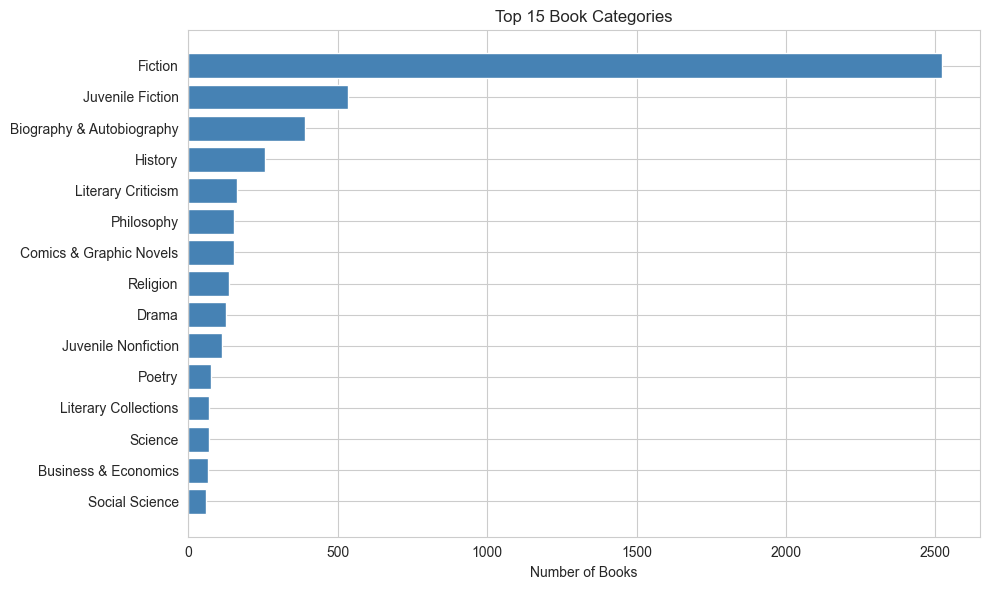

In [8]:
# Analyze book categories distribution
category_counts = complete_books['categories'].value_counts()
category_df = category_counts.reset_index()
category_df.columns = ['category', 'frequency']
category_df = category_df.sort_values('frequency', ascending=False)

print("Top 10 book categories:")
print(category_df.head(10))

# Visualize top categories
plt.figure(figsize=(10, 6))
top_categories = category_df.head(15)
plt.barh(range(len(top_categories)), top_categories['frequency'], color='steelblue')
plt.yticks(range(len(top_categories)), top_categories['category'])
plt.xlabel('Number of Books')
plt.title('Top 15 Book Categories')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Category Distribution Analysis

Understanding the distribution of book categories helps us see what types of books are most common in the dataset. This can inform recommendation strategies and help identify potential biases in the data.


Description word count statistics:
count    6507.000000
mean       66.325803
std        66.120291
min         1.000000
25%        27.000000
50%        40.000000
75%        82.000000
max       920.000000
Name: description_word_count, dtype: float64


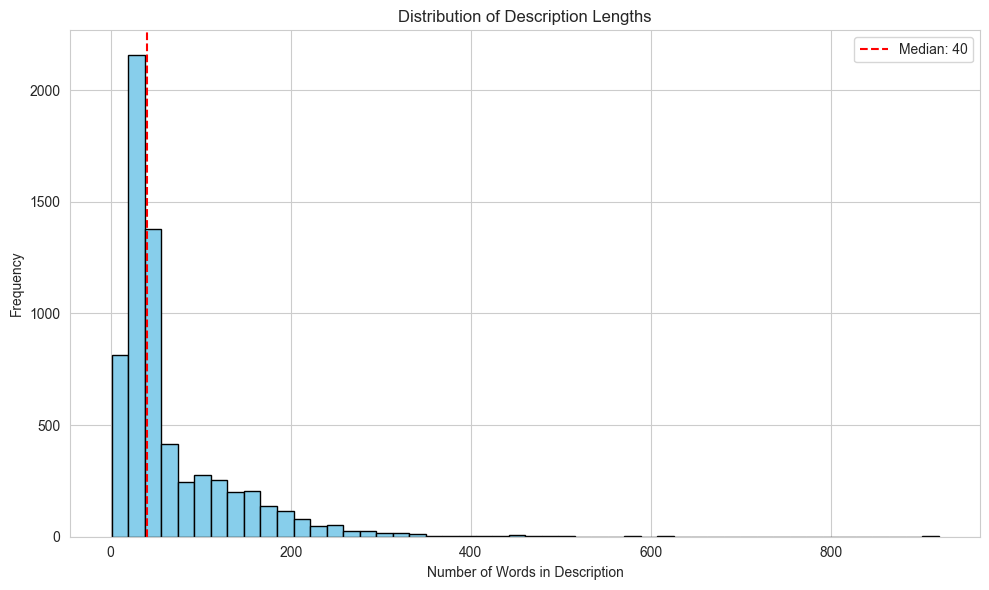

In [9]:
# Calculate description length in terms of word count
complete_books['description_word_count'] = complete_books['description'].apply(
    lambda x: len(str(x).split()) if pd.notna(x) else 0
)

# Display statistics about description lengths
print("Description word count statistics:")
print(complete_books['description_word_count'].describe())

# Visualize distribution of description lengths
plt.figure(figsize=(10, 6))
plt.hist(complete_books['description_word_count'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Number of Words in Description')
plt.ylabel('Frequency')
plt.title('Distribution of Description Lengths')
plt.axvline(complete_books['description_word_count'].median(), 
            color='red', linestyle='--', label=f'Median: {complete_books["description_word_count"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()


## 9. Description Length Analysis

The length of book descriptions is important for semantic search and recommendation systems, so we take the following steps which helps us understand if descriptions are substantial enough for text-based analysis:
- Calculate the word count for each description
- Visualize the distribution of description lengths
- Identify the median length




In [10]:
# Filter books with substantial descriptions (at least 25 words)
# This ensures we have enough text for meaningful analysis
min_words = 25
filtered_books = complete_books[complete_books['description_word_count'] >= min_words].copy()

print(f"Books with at least {min_words} words in description: {len(filtered_books)}")
print(f"Percentage of complete dataset: {len(filtered_books)/len(complete_books)*100:.2f}%")

filtered_books.head()


Books with at least 25 words in description: 5197
Percentage of complete dataset: 79.87%


,isbn13,isbn10,title,subtitle,authors,categories,thumbnail,description,published_year,average_rating,num_pages,ratings_count,has_description,years_since_publication,description_word_count
0,9780002005883,0002005883,Gilead,NaN,Marilynne Robinson,Fiction,http://books.google.com/books/content?id=KQZCP...,A NOVEL THAT READERS and critics have been eag...,2004.0,3.85,247.0,361.0,1,21.0,199
1,9780002261982,0002261987,Spider's Web,A Novel,Charles Osborne;Agatha Christie,Detective and mystery stories,http://books.google.com/books/content?id=gA5GP...,A new 'Christie for Christmas' -- a full-lengt...,2000.0,3.83,241.0,5164.0,1,25.0,205
3,9780006178736,0006178731,Rage of angels,NaN,Sidney Sheldon,Fiction,http://books.google.com/books/content?id=FKo2T...,"A memorable, mesmerizing heroine Jennifer -- b...",1993.0,3.93,512.0,29532.0,1,32.0,57
4,9780006280897,0006280897,The Four Loves,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=XhQ5X...,Lewis' work on the nature of love divides love...,2002.0,4.15,170.0,33684.0,1,23.0,45
5,9780006280934,0006280935,The Problem of Pain,NaN,Clive Staples Lewis,Christian life,http://books.google.com/books/content?id=Kk-uV...,"""In The Problem of Pain, C.S. Lewis, one of th...",2002.0,4.09,176.0,37569.0,1,23.0,75


## 10. Filtering by Description Length

For semantic search and recommendation tasks, we need descriptions with sufficient content. We filter out to keep only books with at least 25 words in their description. This threshold ensures we have enough text for meaningful semantic analysis while maintaining a good dataset size.


In [11]:
# Combine title and subtitle into a single field
# If subtitle exists, combine with colon separator; otherwise use title only
def combine_title_subtitle(row):
    title = str(row['title']) if pd.notna(row['title']) else ''
    subtitle = str(row['subtitle']) if pd.notna(row['subtitle']) else ''
    
    if subtitle and subtitle != 'nan':
        return f"{title}: {subtitle}"
    return title

filtered_books['full_title'] = filtered_books.apply(combine_title_subtitle, axis=1)

# Verify the new column
print("Sample of combined titles:")
print(filtered_books[['title', 'subtitle', 'full_title']].head(10))


Sample of combined titles:
                       title                                        subtitle  \
0                     Gilead                                             NaN   
1               Spider's Web                                         A Novel   
3             Rage of angels                                             NaN   
4             The Four Loves                                             NaN   
5        The Problem of Pain                                             NaN   
7     Empires of the Monsoon  A History of the Indian Ocean and Its Invaders   
8       The Gap Into Madness                                 Chaos and Order   
9         Master of the Game                                             NaN   
12       Warhost of Vastmark                                             NaN   
13  The Once and Future King                                             NaN   

                                           full_title  
0                                   

## 11. Combining Title and Subtitle

Many books have both a title and subtitle. We create a unified field that combines them with a colon separator (e.g., "Title: Subtitle"). If a book doesn't have a subtitle, we will just use the title. This creates a more complete identifier for each book.


In [12]:
# Create a combined text field with ISBN and description for tagging/indexing
filtered_books['indexed_content'] = (
    filtered_books['isbn13'].astype(str) + ' ' + 
    filtered_books['description'].astype(str)
)

# Display sample of the indexed content
print("Sample indexed content (first 200 characters):")
for idx, content in enumerate(filtered_books['indexed_content'].head(3)):
    print(f"\nBook {idx + 1}: {content[:200]}...")


Sample indexed content (first 200 characters):

Book 1: 9780002005883 A NOVEL THAT READERS and critics have been eagerly anticipating for over a decade, Gilead is an astonishingly imagined story of remarkable lives. John Ames is a preacher, the son of a pr...

Book 2: 9780002261982 A new 'Christie for Christmas' -- a full-length novel adapted from her acclaimed play by Charles Osborne Following BLACK COFFEE and THE UNEXPECTED GUEST comes the final Agatha Christie p...

Book 3: 9780006178736 A memorable, mesmerizing heroine Jennifer -- brilliant, beautiful, an attorney on the way up until the Mafia's schemes win her the hatred of an implacable enemy -- and a love more destru...


## 12. Creating Indexed Content & Final Dataset Export

For semantic search and embedding generation, we created a combined text field that includes the ISBN and description. This indexed content can be used for Generating embeddings, Semantic search queries, Text similarity calculations. The ISBN is included to provide a unique identifier within the text content.


Final clean up the dataset by removing intermediate processing columns and export it to a CSV file. The cleaned dataset contains only the essential columns needed for downstream tasks. The final dataset is ready for:
- Semantic search implementation
- Recommendation system development

In [13]:
# Prepare final cleaned dataset for export
# Remove intermediate columns that were used for processing
columns_to_drop = ['subtitle', 'has_description', 'years_since_publication', 'description_word_count']

final_dataset = filtered_books.drop(columns=columns_to_drop)

# Export to CSV file
output_filename = 'books_cleaned.csv'
final_dataset.to_csv(output_filename, index=False)

print(f"Cleaned dataset exported to: {output_filename}")
print(f"Final dataset shape: {final_dataset.shape}")
print(f"\nColumns in final dataset: {list(final_dataset.columns)}")


Cleaned dataset exported to: books_cleaned.csv
Final dataset shape: (5197, 13)

Columns in final dataset: ['isbn13', 'isbn10', 'title', 'authors', 'categories', 'thumbnail', 'description', 'published_year', 'average_rating', 'num_pages', 'ratings_count', 'full_title', 'indexed_content']
